In [12]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18
import numpy as np
import matplotlib.pyplot as plt
import mat73
import scipy.signal as ss
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os
from scipy import signal

'C:\\Users\\Benedetta\\Desktop\\Criticality in barrel cortex\\Codes\\Marianietal2026-PlosCompBio'

In [8]:
plt.rcParams['text.usetex'] =True
plt.rcParams['font.family'] = 'serif',
plt.rcParams['font.serif'] =  'Computer Modern'

In [9]:
local_data_path = "C:/Users/Benedetta/Downloads/Barrel+Talamo/Barrel+Talamo/"

In [137]:
import os
os.chdir(local_data_path)

In [10]:
cd D:

D:\


In [11]:
cd new_data_thalamus/

D:\new_data_thalamus


In [25]:
import os
import numpy as np
import scipy.signal as ss
from scipy import signal
import mat73


# =========================
# Filtering
# =========================

def bandpass_lfp(data, fs, low=0.1, high=50, order=2):
    nyq = 0.5 * fs
    b, a = ss.butter(order, [low/nyq, high/nyq], btype="bandpass")
    return ss.filtfilt(b, a, data, axis=1)


def notch_filter(data, fs, f0=100.0, Q=30.0):
    b, a = ss.iirnotch(f0, Q, fs)
    return ss.filtfilt(b, a, data, axis=1)


def filter_pipeline(data, fs, thalamus=True):
    sig = bandpass_lfp(data, fs)
    if thalamus:
        sig = notch_filter(sig, fs)
    return sig


# =========================
# Epoching
# =========================

def epoch_signal(sig, indexes, fs, pre_sec=1, post_sec=5, nchan=30):
    pre  = int(fs * pre_sec)
    post = int(fs * post_sec)

    n_samples = sig.shape[1]
    trials = []

    for r in range(1, len(indexes) - 1):
        start = indexes[r] - pre
        stop  = indexes[r] + post

        # boundary check
        if start < 0 or stop >= n_samples:
            continue

        trial = sig[:nchan, start:stop]
        trials.append(trial)

    return np.array(trials)


# =========================
# Main processing
# =========================

def process_file(filepath, thalamus=True, fs=25000,pre_sec=1, post_sec=10):
    
    print(os.getcwd(), filepath)
    
    data_dict = mat73.loadmat(filepath)
    data = data_dict['amplifier_data']
    
    stim = data_dict['adc_data'][0] if thalamus else data_dict['adc_data']


    indexes = (np.where(stim > 1.5)[0])[
        np.where(np.diff(np.where(stim > 1.5)[0]) > 1)
    ]
    indexes = np.array(
        indexes.tolist() + 
        [int(indexes[-1] + np.diff(indexes)[-1])]
    ) - 125
    # --------------------------------------------------

    sig = filter_pipeline(data, fs, thalamus=thalamus)
    del data
    nchan = 30 if thalamus else 27
    lfpTrials = epoch_signal(sig, indexes, fs, nchan=nchan, pre_sec=pre_sec, post_sec=post_sec)

    if thalamus:
        lfpTrials = np.delete(lfpTrials, [12,13,14,15,16,17,18,19], axis=1)

    return lfpTrials


# =========================
# Loop rats
# =========================

def run_analysis(nrat=0, start=0, thalamus=True, T = 10 ):

    files = os.listdir()[start:]
    #print(os.listdir())
    file = files[nrat]

    if file == "Figs":
        return None

    lfpTrials = process_file(file, thalamus=thalamus, pre_sec=1, post_sec=T)

    return lfpTrials


rat =int(input('insert rat'))
start =int(input('insert start'))
T = int(input("T"))
lfpTrials = run_analysis(nrat=rat, start=start, thalamus=True, T = T)
    

insert rat 2
insert start 0
T 5


D:\new_data_thalamus Piezo_220211_114822.mat


In [26]:
pwd

'D:\\new_data_thalamus'

In [27]:
downsampled = ss.decimate(lfpTrials,10,axis = 2)
downsampled.shape

(58, 22, 15000)

In [28]:
del lfpTrials

In [30]:
downsampled.shape[0]

58

In [31]:
ch = 17
mm =[]
stdd=[]
for tr in range(downsampled.shape[0]):
    x = downsampled[tr,ch,sample_rate*3:sample_rate*11]
    t = np.arange(0,len(x),1)/sample_rate
    num = int(len(x)/sample_rate)
    #ii = 25 ##attenzione
    imf = emd.sift.mask_sift(x, max_imfs=7, mask_freqs= ii/sample_rate, ret_mask_freq=True)
    IP, IF, IA = emd.spectra.frequency_transform(imf[0], sample_rate, 'nht')
    value_imf = 1
    mask = IF[:,value_imf] > 0
    
    values = IF[:,value_imf][mask]
    weights = IA[:,value_imf][mask]
    #weights = np.ones(values.shape[0])
    # media pesata
    mean = np.average(values, weights=weights)
    
    # std pesata (population)
    variance = np.average((values - mean)**2, weights=weights)
    std = np.sqrt(variance)
    
    # numero efficace
    Neff = (np.sum(weights)**2) / np.sum(weights**2)
    
    # standard error della media pesata
    sem = std / np.sqrt(Neff)
    mm.append(mean)
    stdd.append(std)
    print("mean=", mean)
    print("std =", std)
    print("SEM =", sem)
print(np.mean(mm), np.mean(np.array(stdd)[~np.isnan((stdd))]))

mean= 10.922941193650608
std = 2.7446815020851028
SEM = 0.040384231013959514
mean= 11.458124414242423
std = 8.46864817183507
SEM = 0.12223654517768212
mean= 11.01945762372136
std = 3.2693716914856603
SEM = 0.05070151462205119
mean= 11.739015861518704
std = 2.9465700113477133
SEM = 0.04062127380592729
mean= 11.61087240973451
std = 2.796076599349619
SEM = 0.04684012100133895
mean= 10.90091631991071
std = 1.9890588418000537
SEM = 0.030119570613686173
mean= 11.393417433552996
std = 3.456103588347958
SEM = 0.050155759237210905
mean= 11.071054101515623
std = 2.1281828639650833
SEM = 0.03431350126559687
mean= 10.790784098349526
std = 2.4491016504147134
SEM = 0.0412649016031306
mean= 11.545661141331543
std = 2.200529168618589
SEM = 0.03181739686895646
mean= 11.301956049731654
std = 1.944046332485016
SEM = 0.034547322586649276
mean= 10.69640768237082
std = 2.130258267037494
SEM = 0.03378038553110422
mean= 10.475642084576542
std = 3.0470779235696117
SEM = 0.04611217006540058
mean= 11.18892207950

### Single channels t tests.

In [19]:

import emd
from scipy import signal

fac = 10
final = []
sample_rate=int(25000/fac)
post = 3
ii = 30
for ch in [17]:
    for tr in range(downsampled.shape[0]):
        x = downsampled[tr,ch,sample_rate:sample_rate*post]
        t = np.arange(0,len(x),1)/sample_rate
        num = int(len(x)/sample_rate)
        #ii = 25 ##attenzione
        imf = emd.sift.mask_sift(x, max_imfs=7, mask_freqs= ii/sample_rate, ret_mask_freq=True)
        IP, IF, IA = emd.spectra.frequency_transform(imf[0], sample_rate, 'nht')
        freq_range = (0, 45, 64)
        hht_f, spec = emd.spectra.hilberthuang(IF, IA, freq_range, scaling='density', sum_imfs=False)
        final.append(spec[:,:6])
        #print(spec.shape)
final = np.asarray(final)

import emd
from scipy import signal

fac = 10
final_r = []
sample_rate=int(25000/fac)
start_rest, end_rest = 3,T+1

#3,T+1
#6,8
for ch in [17]:
    for tr in range(downsampled.shape[0]):
        x = downsampled[tr,ch,sample_rate*start_rest:sample_rate*end_rest] 
        
        t = np.arange(0,len(x),1)/sample_rate
        num = int(len(x)/sample_rate)
       #ii = 30
        imf = emd.sift.mask_sift(x, max_imfs=7, mask_freqs= ii/sample_rate, ret_mask_freq=True)
        IP, IF, IA = emd.spectra.frequency_transform(imf[0], sample_rate, 'nht')
        freq_range = (0, 45, 64)
        hht_f, spec = emd.spectra.hilberthuang(IF, IA, freq_range, scaling='density', sum_imfs=False)
        final_r.append(spec[:,:6])
final_r = np.asarray(final_r)

import emd
from scipy import signal
fac = 10
final_th = []
sample_rate=int(25000/fac)
#post = 3

for ch in [8]:
    for tr in range(downsampled.shape[0]):
        x = downsampled[tr,ch,sample_rate:sample_rate*post]
        t = np.arange(0,len(x),1)/sample_rate
        num = int(len(x)/sample_rate)
        #ii = 30 
        imf = emd.sift.mask_sift(x, max_imfs=9, mask_freqs= ii/sample_rate, ret_mask_freq=True)
        IP, IF, IA = emd.spectra.frequency_transform(imf[0], sample_rate, 'nht')
        freq_range = (0, 45, 64)
        hht_f, spec = emd.spectra.hilberthuang(IF, IA, freq_range, scaling='density', sum_imfs=False)
        final_th.append(spec[:,:6])
final_th = np.asarray(final_th)
import emd
from scipy import signal


fac = 10
final_th_r = []
sample_rate=int(25000/fac)

for ch in [8]:
    for tr in range(downsampled.shape[0]):
        x = downsampled[tr,ch,sample_rate*start_rest:sample_rate*end_rest]
        t = np.arange(0,len(x),1)/sample_rate
        num = int(len(x)/sample_rate)
        #ii = 30 
        imf = emd.sift.mask_sift(x, max_imfs=9, mask_freqs= ii/sample_rate, ret_mask_freq=True)
        IP, IF, IA = emd.spectra.frequency_transform(imf[0], sample_rate, 'nht')
        freq_range = (0, 45, 64)
        hht_f, spec = emd.spectra.hilberthuang(IF, IA, freq_range, scaling='density', sum_imfs=False)
        final_th_r.append(spec[:,:6])
final_th_r = np.asarray(final_th_r)



6e-05
0.98514


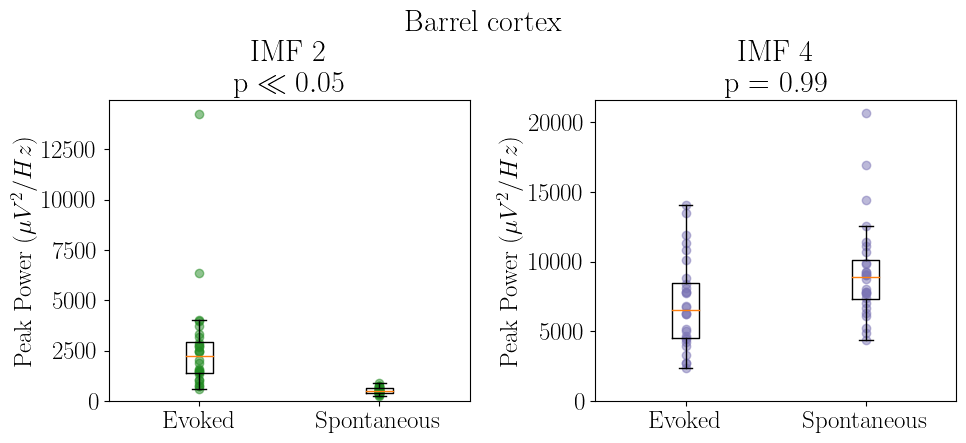

In [20]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import mannwhitneyu, ttest_rel
import warnings
warnings.filterwarnings("ignore")

# ==== PARAMETERS ====
imf_indices = [1, 3]   # IMF 2 e IMF 4
freq_mask = (hht_f >= 0) & (hht_f <= 20)

fig, ax = plt.subplots(1, 2, figsize=(10,5))

for i, imf in enumerate(imf_indices):

    # ---- Peak extraction (within 0–20 Hz) ----
    peak_evoked = np.max(final[:, freq_mask, imf], axis=1)
    peak_spont  = np.max(final_r[:, freq_mask, imf], axis=1)

    # ---- Statistics ----
    stat, p = mannwhitneyu(peak_evoked, peak_spont,alternative ='greater')
    stat, p = ttest_rel(peak_evoked, peak_spont,alternative ='greater')
    
    print(round(p,5))
    # ---- Boxplot ----
    ax[i].boxplot([peak_evoked, peak_spont],
                  labels=['Evoked','Spontaneous'],
                  showfliers=False)
    colors = ['forestgreen', cm.get_cmap('Purples')(0.65)]
    # ---- Scatter overlay (better visualization) ----
    ax[i].scatter(np.ones_like(peak_evoked), peak_evoked, alpha=0.5,color =colors[i])
    ax[i].scatter(np.ones_like(peak_spont)*2, peak_spont, alpha=0.5, color= colors[i])
    if i == 0:
        ax[i].set_title(f"IMF {imf+1}\n " + r"p $\ll  0.05$")
    else:
        ax[i].set_title(f"IMF {imf+1}\n p = {p:.2f}")
    
    ax[i].set_ylabel("Peak Power ($\mu V^2/Hz$)")
    ax[i].set_ylim(bottom=0)
fig.suptitle('Barrel cortex', y = 0.9)
plt.tight_layout()
#plt.show()

0.011383461726739975
0.7440104966551939


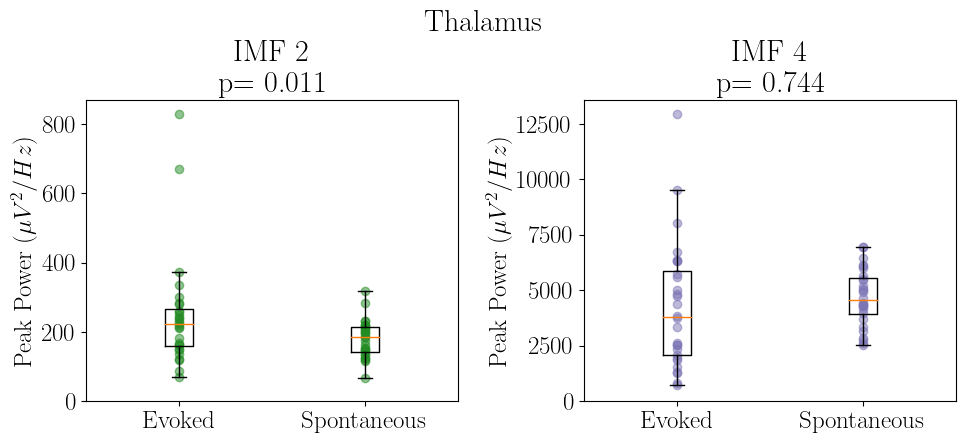

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings("ignore")

# ==== PARAMETERS ====
imf_indices = [1, 3]   # IMF 2 e IMF 4
freq_mask = (hht_f >= 0) & (hht_f <= 20)

fig, ax = plt.subplots(1, 2, figsize=(10,5))

for i, imf in enumerate(imf_indices):

    # ---- Peak extraction (within 0–20 Hz) ----
    peak_evoked = np.max(final_th[:, freq_mask, imf], axis=1)
    peak_spont  = np.max(final_th_r[:, freq_mask, imf], axis=1)

    # ---- Statistics ----
    stat, p = ttest_rel(peak_evoked, peak_spont,alternative ='greater')
    print(p)
    # ---- Boxplot ----
    ax[i].boxplot([peak_evoked, peak_spont],
                  labels=['Evoked','Spontaneous'],
                  showfliers=False)
    color = ['forestgreen', cm.get_cmap('Purples')(0.65)]
    # ---- Scatter overlay (better visualization) ----
    ax[i].scatter(np.ones_like(peak_evoked), peak_evoked, alpha=0.5,color =color[i])
    ax[i].scatter(np.ones_like(peak_spont)*2, peak_spont, alpha=0.5, color=color[i])

    ax[i].set_title(f"IMF {imf+1}\n " + f"p= {round(p,3)}")
    ax[i].set_ylabel("Peak Power ($\mu V^2/Hz$)")
    ax[i].set_ylim(bottom=0)
fig.suptitle('Thalamus', y = 0.9)
plt.tight_layout()
plt.show()